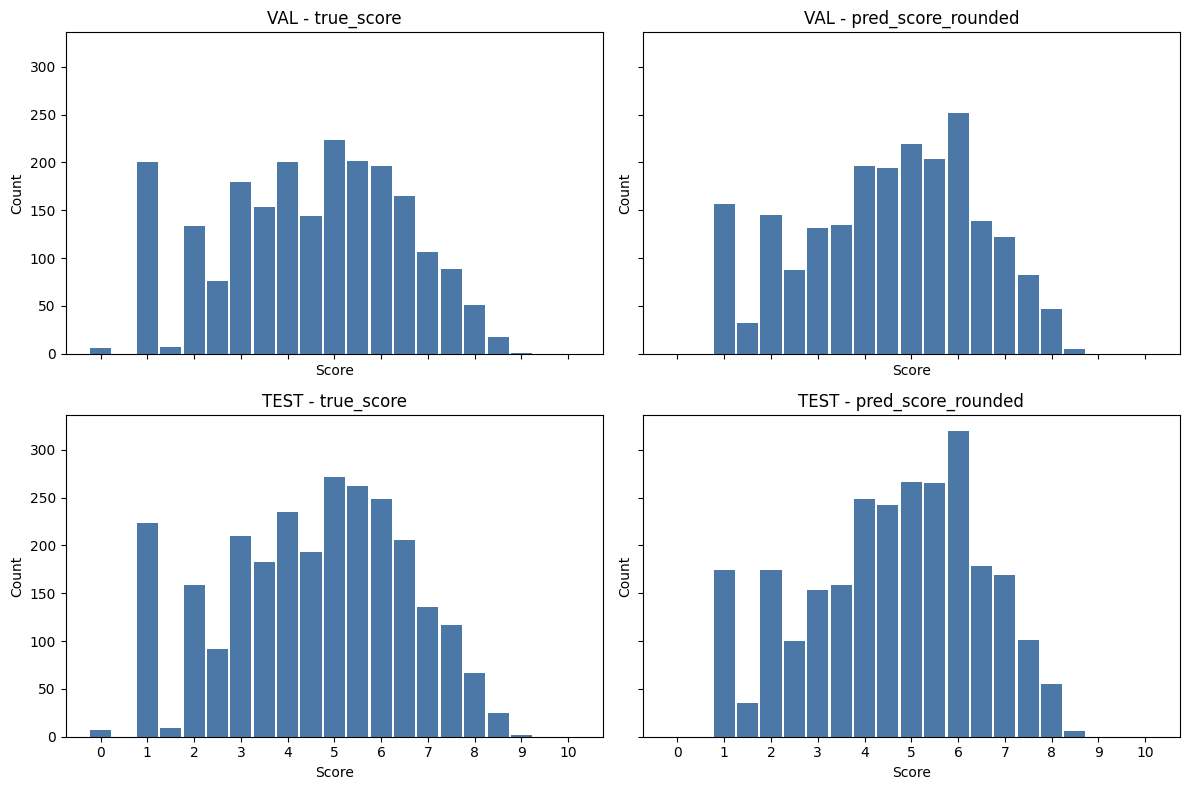

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path('/home/user06/Interspeech_2026/Model/Model/preds_f')
splits = {
    'val': pd.read_csv(base / 'val_predictions.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

bins = np.arange(0.0, 10.5, 0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for row, (name, df) in enumerate(splits.items()):
    for col, score_col in enumerate(["true_score", "pred_score_rounded"]):
        ax = axes[row, col]
        vals = (df[score_col] * 2).round() / 2
        counts = vals.value_counts().reindex(bins, fill_value=0).sort_index()
        ax.bar(bins, counts.values, width=0.45, color="#4C78A8")
        ax.set_title(f"{name.upper()} - {score_col}")
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.set_xticks(np.arange(0, 10.5, 1.0))

plt.tight_layout()
plt.show()



=== VAL ===
MAE 0.5480, MSE 0.6976, RMSE 0.8352, QWK 0.9043
edge_mae 0.5828, mid_mae 0.5052
edge_pred_ratio 0.5040, edge_true_ratio 0.5510
%|err|<=0.5: 70.05%, %|err|<=1.0: 87.28%,  %|err|>1.0: 12.72%,  %|err|>1.5: 4.84%


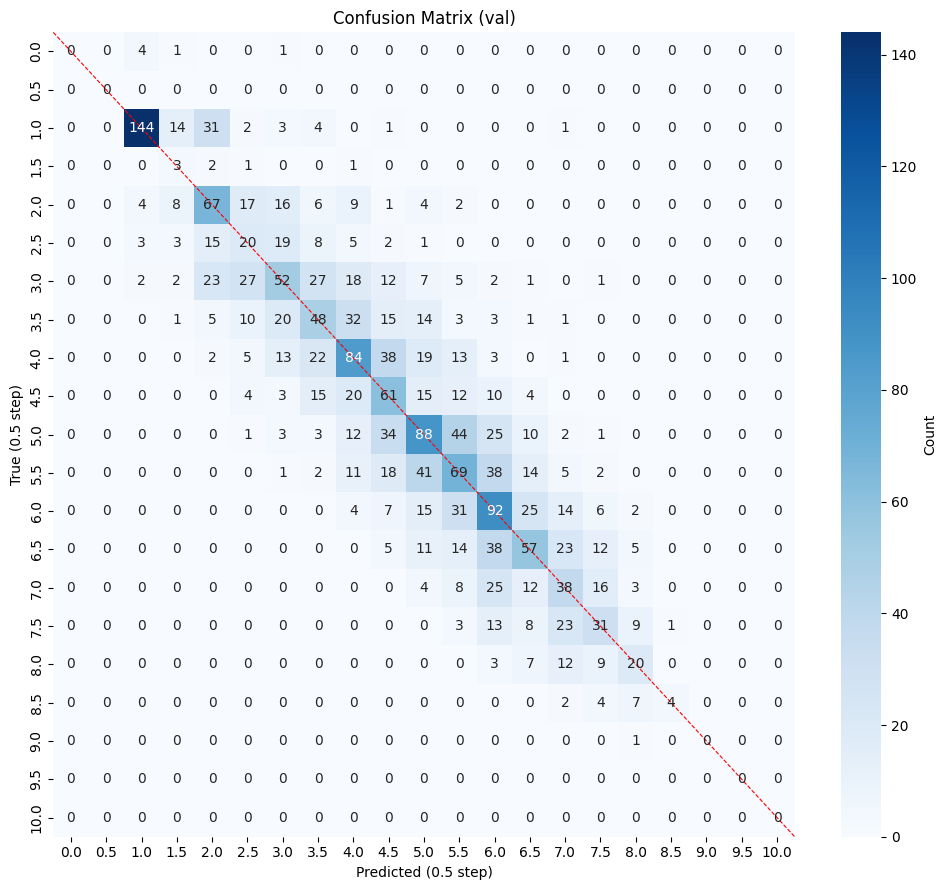


=== TEST ===
MAE 0.5606, MSE 0.7176, RMSE 0.8471, QWK 0.8996
edge_mae 0.6065, mid_mae 0.5062
edge_pred_ratio 0.4930, edge_true_ratio 0.5425
%|err|<=0.5: 69.06%, %|err|<=1.0: 87.16%,  %|err|>1.0: 12.84%,  %|err|>1.5: 4.87%


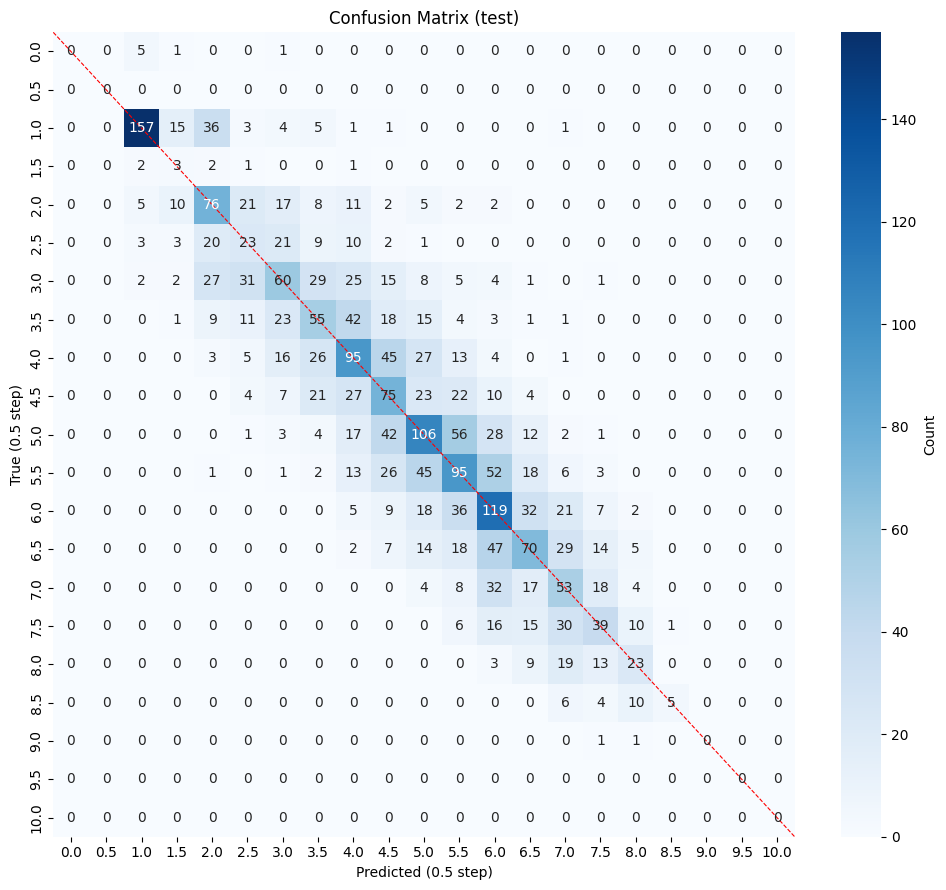

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path

base = Path('/home/user06/Interspeech_2026/Model/Model/preds_final')
splits = {
    # 'train': pd.read_csv(base / 'train_predictions.csv'),
    'val': pd.read_csv(base / 'val_predictions.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

edge_thr = 3.5
labels_int = np.arange(0, 21)         # 0..20 bins (0.5 step)
score_ticks = np.arange(0, 10.5, 0.5) # for axis labels

for name, df in splits.items():
    print(f"\n=== {name.upper()} ===")
    # chỉ lấy các điểm > 0.5
    #df = df[df['true_score'] > 0.5]
    y_true = df['true_score'].to_numpy()
    y_true = np.round(y_true * 2 ) / 2.0
    y_pred = df['pred_score_rounded'].to_numpy()
    y_pred = np.round(y_pred * 2) / 2.0
    err = y_pred - y_true
    abs_err = np.abs(err)

    # Metrics
    mae = np.mean(abs_err)
    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    qwk = cohen_kappa_score(np.round(y_true*2).astype(int),
                            np.round(y_pred*2).astype(int),
                            weights='quadratic')
    edge_mask = (y_true <= edge_thr) | (y_true >= (10 - edge_thr))
    mid_mask = ~edge_mask
    edge_mae = np.mean(abs_err[edge_mask]) if edge_mask.any() else np.nan
    mid_mae = np.mean(abs_err[mid_mask]) if mid_mask.any() else np.nan
    edge_pred_ratio = ((y_pred <= edge_thr) | (y_pred >= (10 - edge_thr))).mean()
    edge_true_ratio = edge_mask.mean()

    pct_le_0_5 = (abs_err <= 0.5).mean()*100
    pct_le_1_0 = (abs_err <= 1.0).mean()*100
    pct_gt_1_0 = (abs_err > 1.0).mean()*100
    pct_gt_1_5 = (abs_err > 1.5).mean()*100
    

    print(f"MAE {mae:.4f}, MSE {mse:.4f}, RMSE {rmse:.4f}, QWK {qwk:.4f}")
    print(f"edge_mae {edge_mae:.4f}, mid_mae {mid_mae:.4f}")
    print(f"edge_pred_ratio {edge_pred_ratio:.4f}, edge_true_ratio {edge_true_ratio:.4f}")
    print(f"%|err|<=0.5: {pct_le_0_5:.2f}%, %|err|<=1.0: {pct_le_1_0:.2f}%,  %|err|>1.0: {pct_gt_1_0:.2f}%,  %|err|>1.5: {pct_gt_1_5:.2f}%")

    # Binning to 0.5 and int labels
    true_bins = np.round(y_true * 2) / 2.0
    pred_bins = np.round(y_pred * 2) / 2.0
    true_lbl = np.round(true_bins * 2).astype(int)
    pred_lbl = np.round(pred_bins * 2).astype(int)

    cm = confusion_matrix(true_lbl, pred_lbl, labels=labels_int)

    plt.figure(figsize=(10, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=score_ticks, yticklabels=score_ticks, cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted (0.5 step)')
    plt.ylabel('True (0.5 step)')
    plt.title(f'Confusion Matrix ({name})')
    plt.plot([0, len(labels_int)], [0, len(labels_int)], color='red', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()


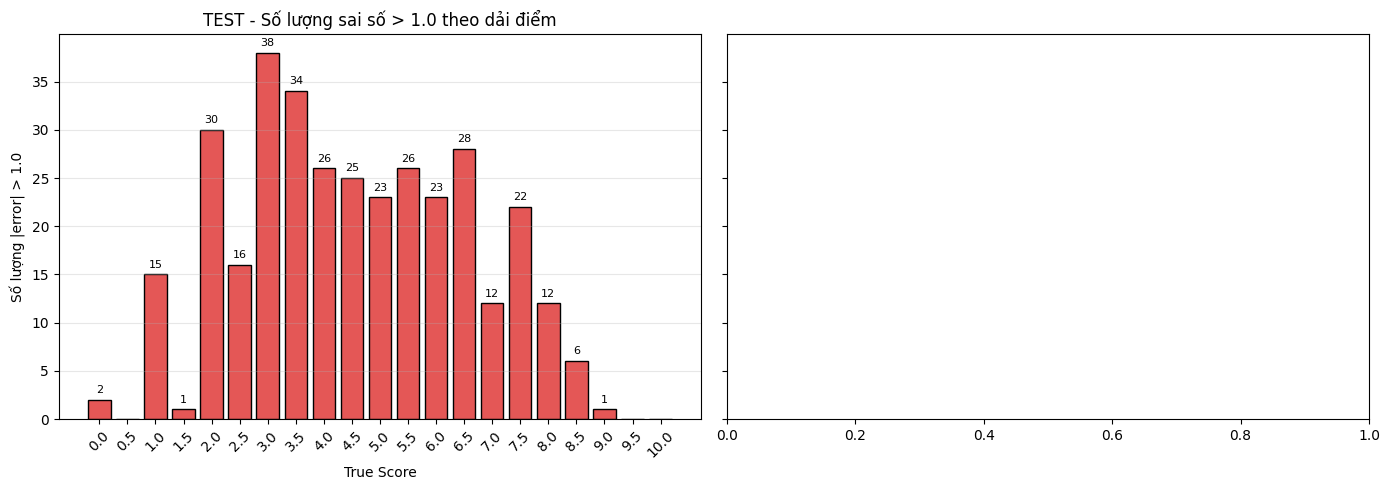


=== TEST ===
Score    Total    |err|>1    %       
------------------------------------
0.0      7        2          28.6    
1.0      223      15         6.7     
1.5      9        1          11.1    
2.0      159      30         18.9    
2.5      92       16         17.4    
3.0      210      38         18.1    
3.5      183      34         18.6    
4.0      235      26         11.1    
4.5      193      25         13.0    
5.0      272      23         8.5     
5.5      262      26         9.9     
6.0      249      23         9.2     
6.5      206      28         13.6    
7.0      136      12         8.8     
7.5      117      22         18.8    
8.0      67       12         17.9    
8.5      25       6          24.0    
9.0      2        1          50.0    


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path('/home/user06/Interspeech_2026/Model/Model/preds_final')
splits = {
    #'val': pd.read_csv(base / 'val_predictions.csv'),
    #'val': pd.read_csv('/home/user06/data/Speaking_VSTEP/Test_V2/with_instruction/unseen/train_full_3dot.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

# Định nghĩa các dải điểm (0.5 step)
score_bins = np.arange(0, 10.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, splits.items()):
    y_true = df['true_score'].to_numpy()
    y_true = np.round(y_true * 2) / 2.0
    y_pred = df['pred_score_rounded'].to_numpy()
    y_pred = np.round(y_pred * 2) / 2.0
    abs_err = np.abs(y_pred - y_true)
    
    # Làm tròn true_score về bước 0.5
    true_bins = np.round(y_true * 2) / 2.0
    
    # Đếm số lượng sai số > 1 trên từng dải điểm
    error_counts = []
    for score in score_bins:
        mask = (true_bins == score) & (abs_err > 1.0)
        error_counts.append(mask.sum())
    
    # Vẽ biểu đồ cột
    bars = ax.bar(score_bins, error_counts, width=0.4, color='#E45756', edgecolor='black')
    
    # Thêm số liệu trên mỗi cột
    for bar, count in zip(bars, error_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'{name.upper()} - Số lượng sai số > 1.0 theo dải điểm')
    ax.set_xlabel('True Score')
    ax.set_ylabel('Số lượng |error| > 1.0')
    ax.set_xticks(score_bins)
    ax.set_xticklabels([f'{s:.1f}' for s in score_bins], rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# In thống kê chi tiết
for name, df in splits.items():
    print(f"\n=== {name.upper()} ===")
    y_true = df['true_score'].to_numpy()
    y_pred = df['pred_score_rounded'].to_numpy()
    abs_err = np.abs(y_pred - y_true)
    true_bins = np.round(y_true * 2) / 2.0
    
    print(f"{'Score':<8} {'Total':<8} {'|err|>1':<10} {'%':<8}")
    print("-" * 36)
    for score in score_bins:
        total = (true_bins == score).sum()
        err_gt_1 = ((true_bins == score) & (abs_err > 1.0)).sum()
        pct = (err_gt_1 / total * 100) if total > 0 else 0
        if total > 0:
            print(f"{score:<8.1f} {total:<8} {err_gt_1:<10} {pct:<8.1f}")

In [17]:
# Filter out all samples with |error| > 1.0
for name, df in splits.items():
    y_true = df['true_score'].to_numpy()
    y_pred = df['pred_score_rounded'].to_numpy()
    abs_err = np.abs(y_pred - y_true)
    filtered_df = df[abs_err > 1.0]
    print(f"{name.upper()} - Original samples: {len(df)}, After filtering: {len(filtered_df)}")

# Save filtered dataframes if needed
filtered_df.to_csv(base / f'{name}_filtered_err_gt_1.csv', index=False)

TEST - Original samples: 2647, After filtering: 340


In [13]:
import pandas as pd

inp = "/home/user06/Interspeech_2026/Model/Model/preds_final/metadata.csv"
out = "/home/user06/Interspeech_2026/Model/Model/preds_final/File_chấm_điểm.csv"

df = pd.read_csv(inp)

id_col = "Mã Thí Sinh"
path_col = "Đường Dẫn"

# Giữ các cột khác (nếu có) lấy giá trị đầu tiên không null
other_cols = [c for c in df.columns if c not in [id_col, path_col]]

def pad3(lst):
    lst = list(lst)
    return (lst + ["", "", ""])[:3]

grouped = (
    df.groupby(id_col, sort=False)
      .agg({**{path_col: list}, **{c: "first" for c in other_cols}})
      .reset_index()
)

parts = grouped[path_col].apply(pad3)
grouped["Đường Dẫn part 1"] = parts.apply(lambda x: x[0])
grouped["Đường Dẫn part 2"] = parts.apply(lambda x: x[1])
grouped["Đường Dẫn part 3"] = parts.apply(lambda x: x[2])
grouped = grouped.drop(columns=[path_col])

grouped.to_csv(out, index=False)
